In [19]:
from data_utils import *


DATA_ROOT = "../outputs/combined/"
FIGURE_ROOT = Path("../outputs/plots/bias")
N_RUNS = 100
N_EXAMPLES = 50000

model_df = get_model_df(DATA_ROOT)
model_df = model_df[model_df["dataset_key"] != "cinic10nocifarsubset"]
model_df

,model_key,dataset_key,Model,Dataset,Task,Parameters,path,key,n_replicates
0,cifar_resnet_20_64,cifar10,ResNet wide,CIFAR-10,CIFAR-10/ResNet wide,4327754,../outputs/combined/lottery_018683f0568061c3a8...,lottery_018683f0568061c3a8b71ab3591569b8,100
1,cifar_vgg_16,cifar100,VGG-16,CIFAR-100,CIFAR-100/VGG-16,14728266,../outputs/combined/lottery_06562e05cda1bf840e...,lottery_06562e05cda1bf840ee146490815ed82,100
2,cifar_resnet_32,cifar10,ResNet deep,CIFAR-10,CIFAR-10/ResNet deep,466906,../outputs/combined/lottery_323890dc4552d843f9...,lottery_323890dc4552d843f9a1fcfe3da775bf,100
4,cifar_resnet_20,cifar10,ResNet-20 (LR=0.01),CIFAR-10,CIFAR-10/ResNet-20 (LR=0.01),272474,../outputs/combined/lottery_775f113b9c14d804ba...,lottery_775f113b9c14d804ba7b473e4ebc835f,100
5,cifar_resnet_20,cifar10,ResNet-20,CIFAR-10,CIFAR-10/ResNet-20,272474,../outputs/combined/lottery_8ae667adac9b690a88...,lottery_8ae667adac9b690a88b522e85f1388c8,100
6,cifar_resnet_20,cifar100,ResNet-20,CIFAR-100,CIFAR-100/ResNet-20,272474,../outputs/combined/lottery_9dc2b8dfff54c4da57...,lottery_9dc2b8dfff54c4da57570d7b391dcccd,100
7,cifar_resnet_20_64,cifar100,ResNet wide,CIFAR-100,CIFAR-100/ResNet wide,4327754,../outputs/combined/lottery_a8299123c240af67e9...,lottery_a8299123c240af67e983ad684c69ecb9,100
8,cifar_vgg_16,cifar10,VGG-16,CIFAR-10,CIFAR-10/VGG-16,14728266,../outputs/combined/lottery_cf40a5a8bbe4f285b8...,lottery_cf40a5a8bbe4f285b8fe317c1aa95dd5,100
9,cifar_resnet_20,cifar10,ResNet-20 (Adam),CIFAR-10,CIFAR-10/ResNet-20 (Adam),272474,../outputs/combined/lottery_efe7d47fb664dce783...,lottery_efe7d47fb664dce78349cfa2ff31da4c,100


In [5]:
CV_MODELS = [
    "ResNet-20",
    "ResNet-20 (Adam)",
    "ResNet-20 (LR=0.01)",
    "ResNet wide",
    "ResNet deep",
    "VGG-16",
]

SELECTED_SCORES = [
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_ret"},
]

ALL_SCORES = [
    {"key": "carlini_agr"},
    {"key": "ddd",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 160},
    {"key": "ddd",
    "Method": "Ensemble",
    "Type": "",
    "Epoch": 20},
    {"key": "acc",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "acc",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "loss",
    "Method": "Training",
    "Type": ""},
    {"key": "margin",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "conf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "maxconf",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "carlini_conf"},
    {"key": "batch_countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "countforget",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstlearn",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "firstunforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "batch_unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "unforgettable",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "el2n",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "el2n",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "grand",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "classvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "lossvog",
    "Method": "Training",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "proto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "selfproto",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "swav_selfproto"},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 160},
    {"key": "pd",
    "Method": "One Step",
    "Type": "",
    "Epoch": 20},
    {"key": "carlini_ret"},
    {"key": "carlini_adv"},
    {"key": "carlini_priv"},
    {"key": "memorization"},
    {"key": "memorization_inception"},
]

In [16]:
import warnings
from itertools import product, combinations
from scipy.stats import ttest_ind
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA, FactorAnalysis
from scipy.optimize import linear_sum_assignment
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression


def plot_pca(X, y_true, y_pred=None, name=None, ax=None, title=None, x_label=None):
    n_components = min(2, X.shape[1], len(set(y_true)) - 1)
    pca = PCA(n_components=n_components)
    pca = pca.fit(X, y_true)
    X_r2 = pca.transform(X)
    x_values = X_r2[:, 0]  if n_components > 1 else X[:, 0]
    y_values = X_r2[:, 1] if n_components > 1 else np.random.uniform(-0.5, 0.5, size=X_r2[:, 0].shape)

    ax = sns.scatterplot(x=x_values, y=y_values, hue=y_true, style=y_pred, ax=ax)
    ax.set_xlabel("PCA 1" if x_label is None else x_label)
    ax.set_ylabel("PCA 2" if n_components > 1 else "")
    if title is not None:
        ax.set_title(title)
    if n_components > 1:
        ax.set(xticklabels=[])
    else:
        ax.set_ylim(-1, 1)  # make it look like a strip plot
    ax.set(yticklabels=[])

    if title is not None:
        save_fig(FIGURE_ROOT, "pca", name=name)
    return pca, ax


def get_features(df, select_attrs=None, idx=None, avg_over_examples=False, normalize=True, merge_score_dim=True):
    stds, means = [], []
    features, targets = [], []

    for model, sub_df in df.groupby("Model"):
        std, mean  = [], []
        model_features = []

        rows = [(x, x["array"]) for _, x in sub_df.iterrows()] if select_attrs is None else get_selected_scores(sub_df, select_attrs, strict=False)
        for row, score in rows:
            # get mean, std over all examples and runs, whether they are selected or not
            std.append(np.std(score))
            mean.append(np.mean(score))

            if idx is not None:
                score = score[:, idx]
            if avg_over_examples:
                score = np.mean(score, axis=1, keepdims=True)
            model_features.append(score)  # (runs, examples)

        stds.append(np.stack(std))
        means.append(np.stack(mean))
        features.append(np.stack(model_features, axis=-1))  # (runs, examples, scores)
        targets += [model] * len(score)  # (runs,)

    features = np.concatenate(features, axis=0)  # (models * runs, examples, scores)

    if normalize:  # standardize over each score to make them comparable
        # average over all models to get one scaling factor per score
        means = np.mean(np.stack(means), axis=0)
        stds = np.mean(np.stack(stds, axis=0), axis=0)  # (scores,)
        features = (features - means) / stds

    if merge_score_dim:
        features = features.reshape(features.shape[0], -1)

    return features, targets


def rename_labels(labels, mapping_dict):
    return [mapping_dict[x] for x in labels]


def one_hot_encoding(labels, size=None):
    ids = [None for _ in range(size)]
    for i, l in enumerate(np.unique(labels)):
        ids[i] = l
    if size is None:
        size = len(ids)
    labels_to_ids = {j: i for i, j in enumerate(ids)}
    y = rename_labels(labels, labels_to_ids)
    output = np.zeros([len(labels), size])
    output[np.arange(len(labels)), y] = 1
    return output, ids


def match_labels(pred_y, true_y, n_labels):
    A, pred_labels = one_hot_encoding(pred_y, n_labels)
    B, true_labels = one_hot_encoding(true_y, n_labels)
    cost = A.T @ B
    r, c = linear_sum_assignment(cost, maximize=True)
    true_to_pred = {true_labels[i]: pred_labels[j] for i, j in zip(r, c)}
    pred_to_true = {pred_labels[i]: true_labels[j] for i, j in zip(r, c)}
    return pred_to_true, true_to_pred


def fit_kmeans(X, y):
    cluster = KMeans(len(set(y)))
    cluster.fit(X)
    return cluster


def fit_lda(X, y):
    n_components = min(X.shape[1], len(set(y)) - 1)
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    lda.fit(X, y)
    return lda


def fit_logistic(X, y, C=1, penalty="l2"):
    solver = "lbfgs" if penalty == "l2" else "saga"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        classifier = LogisticRegression(penalty=penalty, solver=solver, C=C, max_iter=5e3)
    classifier.fit(X, y)
    return classifier


def fit_logistic_tuned(X, y, plot=False, cv_folds=4, Cs=None, penalty="l2"):
    if Cs is None:
        Cs = [10**c for c in np.linspace(-2, 3, 6)]
    accs = []
    for i in range(cv_folds):
        train_idx = np.ones(len(y), dtype=bool)
        train_idx[np.arange(i, len(y), cv_folds)] = False
        val_idx = np.logical_not(train_idx)
        X_tr, y_tr = X[train_idx], np.array(y)[train_idx]
        X_val, y_val = X[val_idx], np.array(y)[val_idx]
        acc = []
        for c in Cs:
            logreg = fit_logistic(X_tr, y_tr, C=c, penalty=penalty)
            _, a = predict(logreg, X_val, y_val)
            acc.append(a)
        accs.append(np.array(acc))
    accs = np.mean(np.stack(accs), axis=0)
    if plot:
        ax = sns.lineplot(x=Cs, y=accs)
        ax.set_xscale("log")
        plt.show()
    i = np.argmax(accs)
    return fit_logistic(X, y, C=Cs[i], penalty=penalty)


def predict(obj, X, y):
    y_pred = obj.predict(X)
    if isinstance(obj, KMeans):
        pred_to_true, _ = match_labels(y_pred, y, obj.n_clusters)
        y_pred = rename_labels(y_pred, pred_to_true)
    accuracy = np.mean([a == b for a, b in zip(y_pred, y)])
    return y_pred, accuracy


def plot_cluster_acc_vs_n_examples(cluster_df, name=None):
    ax = sns.lineplot(data=cluster_df, x="Number of Examples", y="Classification Accuracy", 
    hue="Example Selection", style="Distribution")
    ax.set_ylim(0, 1)
    ax.set_xscale("log")
    save_fig(FIGURE_ROOT, "cluster", name=name)


def split_replicates(df, replicate_idx, n_replicates):
    replicate_idx = np.sort(replicate_idx)
    test_idx = np.delete(np.arange(n_replicates), replicate_idx)
    id_array = df["array"].apply(lambda x: x[replicate_idx] if len(x) == n_replicates else x)
    ood_array = df["array"].apply(lambda x: x[test_idx] if len(x) == n_replicates else x)
    id_df = df.assign(array=id_array, Replicate=[replicate_idx] * len(df))
    ood_df = df.assign(array=ood_array, Replicate=[test_idx] * len(df))
    return id_df, ood_df


def train_and_test(df, fit_fns, test_frac=0.5, x_label=None, avg_examples=False, metadata={}, plot=False):
    do_normalize = x_label is None
    train_df, test_df = split_replicates(df, np.random.permutation(N_RUNS)[:int(test_frac*N_RUNS)], N_RUNS)
    # if doing a single score, don't normalize for the plots
    X_tr, y_tr = get_features(train_df, avg_over_examples=avg_examples, normalize=do_normalize)
    X_te, y_te = get_features(test_df, avg_over_examples=avg_examples, normalize=do_normalize)

    result_df = []
    for name, fit_fn in fit_fns:
        # if doing a single score, standardize X_tr and X_te with the same mean/std here, otherwise logistic regression may fail
        std, mean = 1, 0
        if not do_normalize:
            X = np.concatenate([X_tr.reshape(-1), X_te.reshape(-1)])
            std, mean = np.std(X), np.mean(X)
        model_obj = fit_fn((X_tr - mean) / std, y_tr)
        y_pred, acc = predict(model_obj, (X_te - mean) / std, y_te)
        result_df.append({
            "Method": name,
            "Accuracy": acc,
            "Predictions": y_pred,
            "Object": model_obj,
            **metadata,
        })
    result_df = pd.DataFrame(result_df)

    if plot:
        for _, row in result_df.iterrows():
            _, ax = plot_pca(X_te, y_te, row["Predictions"], x_label=x_label)
            ax.set_title(f'{row["Method"]} {row["Accuracy"]*100:0.0f}%')
            save_fig(FIGURE_ROOT, "pca", "_".join(x for x in metadata.values()) + "_" + row["Method"])
    return result_df

In [10]:
FIT_FUNCTIONS = [
    ("K-Means", fit_kmeans),
    ("Logistic", fit_logistic_tuned),
]

N_ITERS = 5

LOSS_SCORES = [
    {"key": "loss",
    "Method": "One Step",
    "Type": ""},
]

In [ ]:
dfs = []
for _, model_row in model_df.iterrows():
    print(model_row)
    task_name = model_row["Task"]

    score_df = get_score_df(model_row, n_replicates=N_RUNS)
    score_df = score_df[score_df["Epoch"] != 0]
    loss_df = multi_filter_df(score_df, LOSS_SCORES)
    score_df = multi_filter_df(score_df, SELECTED_SCORES)
    df = get_scores(score_df, n_examples=N_EXAMPLES, fuzz_by=0, invert=True)
    training_loss = aggregate_steps(get_scores(loss_df, n_examples=N_EXAMPLES, fuzz_by=0, invert=False))
    training_loss["Epoch"] = training_loss["Epoch"].apply(lambda x: max(x))
    df = pd.concat([df, training_loss])
    df = df[(df["Method"] != "Ensemble")]
    df["Model"] = model_row["Model"]
    df["Dataset"] = model_row["Dataset"]
    dfs.append(df)
dfs = pd.concat(dfs)

cifar10_df = dfs[dfs["Dataset"] == "CIFAR-10"]
dfs


model_key                                      cifar_resnet_20_64
dataset_key                                               cifar10
Model                                                 ResNet wide
Dataset                                                  CIFAR-10
Task                                         CIFAR-10/ResNet wide
Parameters                                                4327754
path            ../outputs/combined/lottery_018683f0568061c3a8...
key                      lottery_018683f0568061c3a8b71ab3591569b8
n_replicates                                                  100
Name: 0, dtype: object
model_key                                            cifar_vgg_16
dataset_key                                              cifar100
Model                                                      VGG-16
Dataset                                                 CIFAR-100
Task                                             CIFAR-100/VGG-16
Parameters                                           

,Path,Replicate,Epoch,Method,Short Name,Full Name,Type,key,is_fuzzed,is_inverted,array,Model,Dataset
0,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,Forgetting,Forgetting,,batch_countforget,False,False,"[[5.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0,...",ResNet wide,CIFAR-10
1,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,VoG,VoG,,classvog,False,False,"[[0.00012768529235164175, 1.4152428382892776e-...",ResNet wide,CIFAR-10
2,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",20,One Step,EL2N,EL2N (20ep),,el2n,False,False,"[[0.0015033168993041667, 7.552238875753661e-06...",ResNet wide,CIFAR-10
3,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,Area Under Margin,Area Under Margin,,margin,False,True,"[[-0.9459145794920557, -0.9996723953172145, -0...",ResNet wide,CIFAR-10
4,../outputs/combined/lottery_018683f0568061c3a8...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,One Step,Prediction Depth,Prediction Depth (160ep),,pd,False,False,"[[7, 7, 8, 1, 4, 7, 7, 4, 7, 8, 3, 7, 8, 7, 7,...",ResNet wide,CIFAR-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",20,One Step,EL2N,EL2N (20ep),,el2n,False,False,"[[0.010289327296884272, 8.824582793563705e-07,...",ResNet-20 (Adam),CIFAR-10
3,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,Training,Area Under Margin,Area Under Margin,,margin,False,True,"[[-0.8779799243163615, -0.9666146269355793, -0...",ResNet-20 (Adam),CIFAR-10
4,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,One Step,Prediction Depth,Prediction Depth (160ep),,pd,False,False,"[[4, 6, 8, 0, 4, 4, 8, 4, 3, 6, 4, 6, 8, 6, 6,...",ResNet-20 (Adam),CIFAR-10
5,../outputs/combined/lottery_efe7d47fb664dce783...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",160,One Step,Self-Supervised Prototypes,Self-Supervised Prototypes (160ep),,selfproto,False,False,"[[2.766862588562788, 2.17732633050522, 3.39148...",ResNet-20 (Adam),CIFAR-10


Saving figure to ../outputs/plots/bias/Selected_Aggregate_lda.pdf


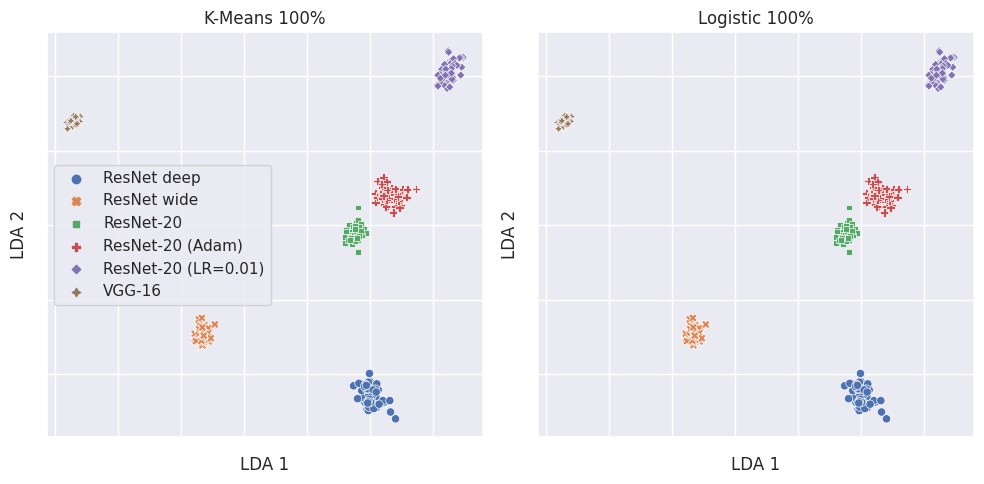

Saving figure to ../outputs/plots/bias/Selected_Per-Example_lda.pdf


<Figure size 640x480 with 0 Axes>

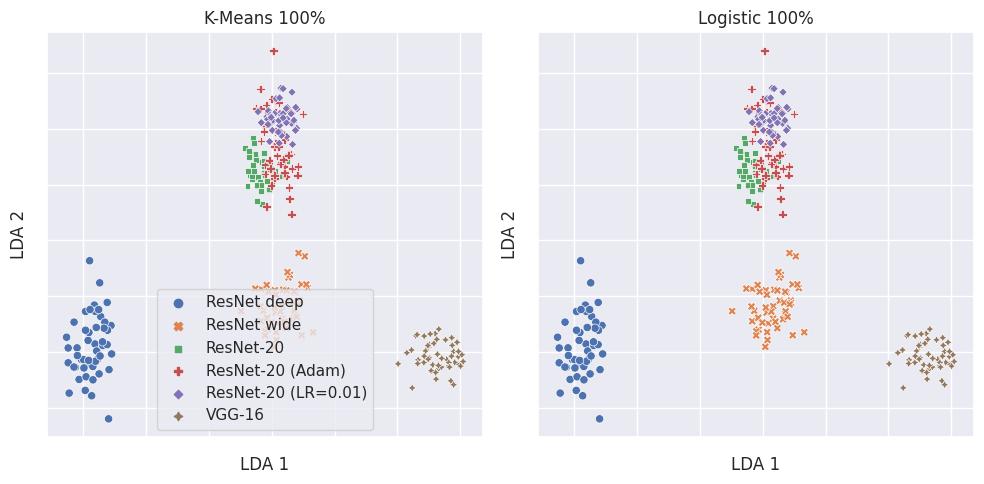

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/ipykernel_launcher.py:106: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number o

Saving figure to ../outputs/plots/bias/Selected_Aggregate_lda.pdf


<Figure size 640x480 with 0 Axes>

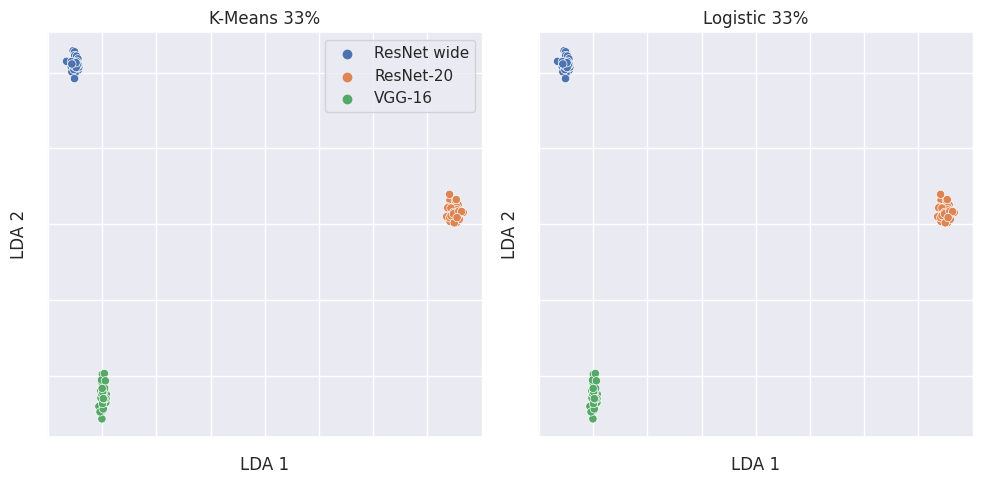

/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/ipykernel_launcher.py:106: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/home/devin/e/.cache/miniconda3/envs/ml-torch/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number o

Saving figure to ../outputs/plots/bias/Selected_Per-Example_lda.pdf


<Figure size 640x480 with 0 Axes>

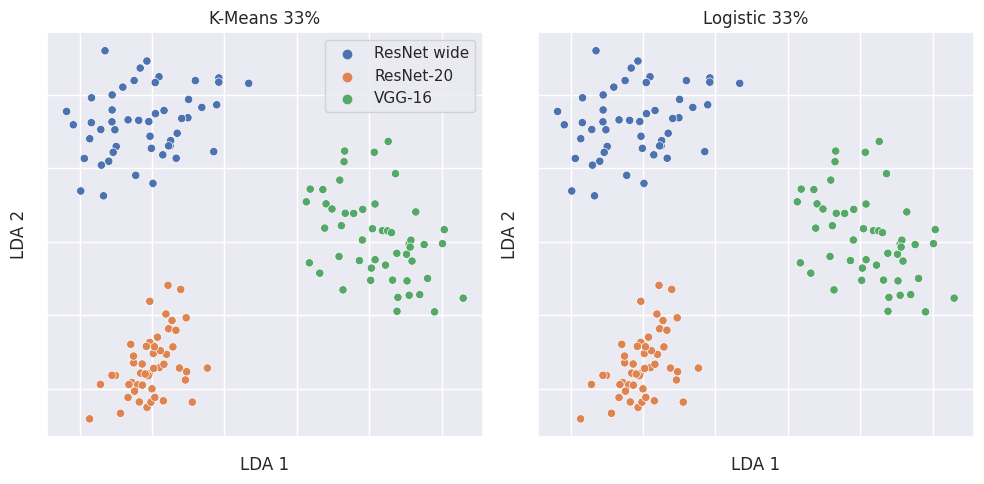

<Figure size 640x480 with 0 Axes>

In [ ]:
# first, cluster over all aggregated scores
for dataset, df in dfs.groupby("Dataset"):
    train_and_test(df, FIT_FUNCTIONS, metadata={"dataset": dataset, "title": "Selected Aggregate"}, avg_examples=True, plot=True)
    train_and_test(df, FIT_FUNCTIONS, metadata={"dataset": dataset, "title": "Selected Per-Example"}, avg_examples=False, plot=True)

Saving figure to ../outputs/plots/bias/cifar10_aggregate_vs_per_example_class_K-Means.pdf


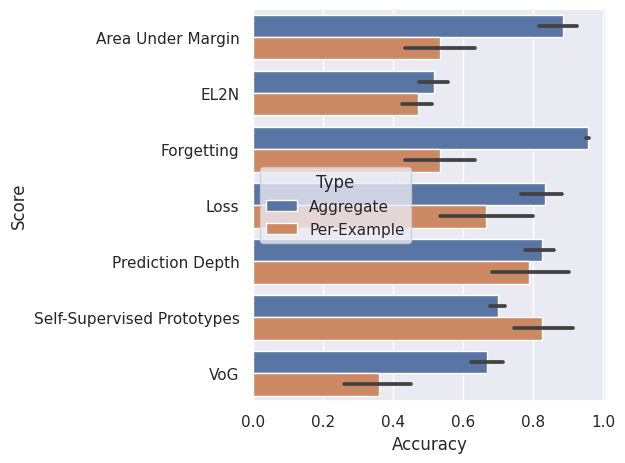

Saving figure to ../outputs/plots/bias/cifar10_aggregate_vs_per_example_class_Logistic.pdf


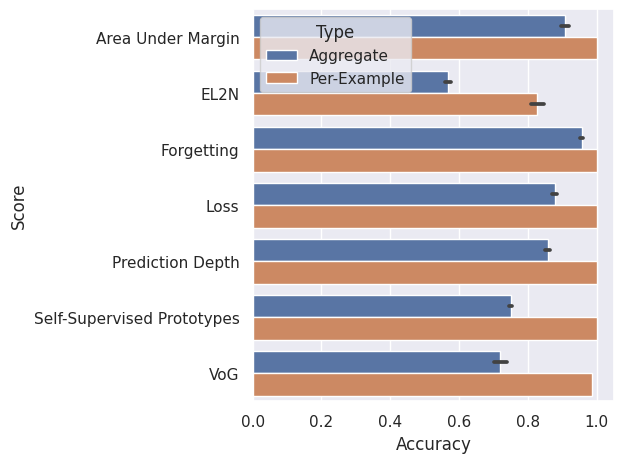

<Figure size 640x480 with 0 Axes>

In [ ]:
# # for each score, compare aggregate vs per-example scores
# result_df = []
# for score_name, df in cifar10_df.groupby(["Short Name"]):
#     metadata = {
#         "Score": score_name,
#     }
#     for i in range(N_ITERS):
#         result_df.append(train_and_test(df, FIT_FUNCTIONS, x_label=score_name, avg_examples=True, metadata={"Score": score_name, "Type": "Aggregate"}, plot=(i == 0)))
#         result_df.append(train_and_test(df, FIT_FUNCTIONS, avg_examples=False, metadata={"Score": score_name, "Type": "Per-Example"}, plot=(i == 0)))
# result_df = pd.concat(result_df)
# result_df

result_df = pd.read_csv("../outputs/plots/bias/bias_agg_vs_per_example_single_scores.csv")

for method, sub_df in result_df.groupby("Method"):
    ax = sns.barplot(data=sub_df, y="Score", x="Accuracy", hue="Type")
    save_fig(FIGURE_ROOT, f"aggregate_vs_per_example_class_{method}", "cifar10")

In [ ]:
# plot just aggregate loss after training
FINAL_TRAIN_LOSS = {
    "key": "loss",
    "Method": "One Step",
    "Epoch": 160,
    "Type": ""
}


dfs = []
for _, model_row in model_df.iterrows():
    print(model_row)
    task_name = model_row["Task"]

    score_df = get_score_df(model_row, n_replicates=N_RUNS)
    score_df = filter_df(score_df, FINAL_TRAIN_LOSS)
    df = get_scores(score_df, n_examples=N_EXAMPLES, fuzz_by=0, invert=False)
    df["Model"] = model_row["Model"]
    df["Dataset"] = model_row["Dataset"]
    dfs.append(df)
dfs = pd.concat(dfs)

model_key                                      cifar_resnet_20_64
dataset_key                                               cifar10
Model                                                 ResNet wide
Dataset                                                  CIFAR-10
Task                                         CIFAR-10/ResNet wide
Parameters                                                4327754
path            ../outputs/combined/lottery_018683f0568061c3a8...
key                      lottery_018683f0568061c3a8b71ab3591569b8
n_replicates                                                  100
Name: 0, dtype: object
model_key                                            cifar_vgg_16
dataset_key                                              cifar100
Model                                                      VGG-16
Dataset                                                 CIFAR-100
Task                                             CIFAR-100/VGG-16
Parameters                                           

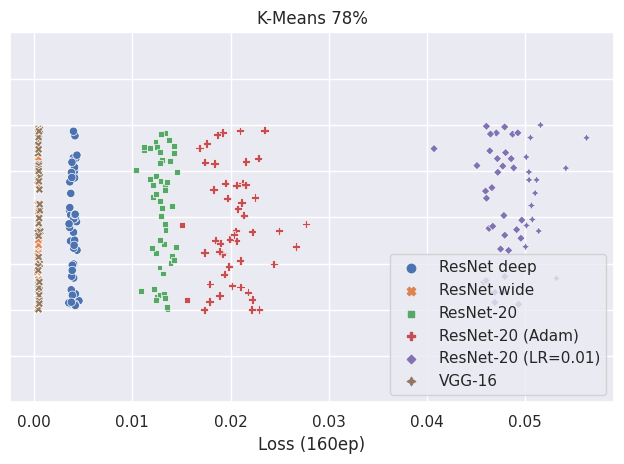

Saving figure to ../outputs/plots/bias/Loss_160ep_Aggregate_CIFAR-10_Logistic_pca.pdf


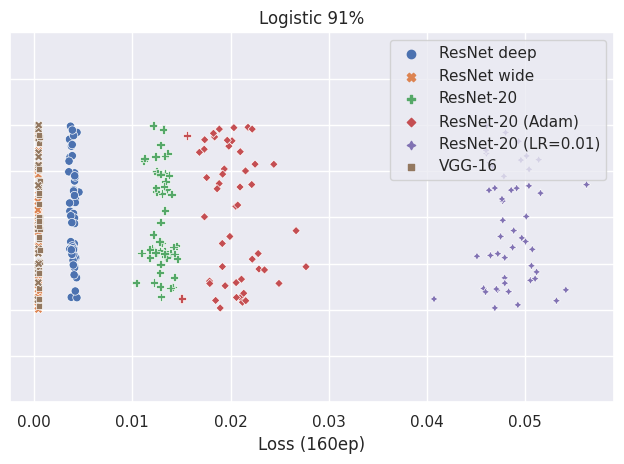

Saving figure to ../outputs/plots/bias/Loss_160ep_Per-Example_CIFAR-10_K-Means_pca.pdf


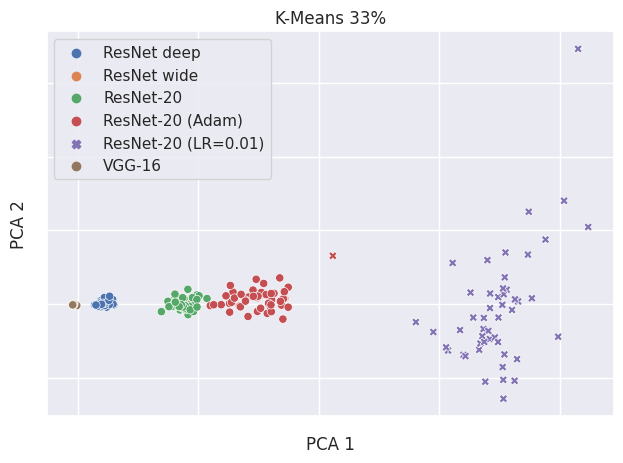

Saving figure to ../outputs/plots/bias/Loss_160ep_Per-Example_CIFAR-10_Logistic_pca.pdf


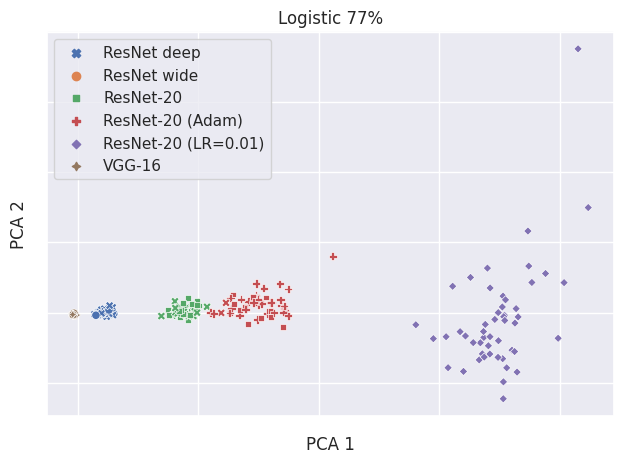

Saving figure to ../outputs/plots/bias/Loss_160ep_Aggregate_CIFAR-100_K-Means_pca.pdf


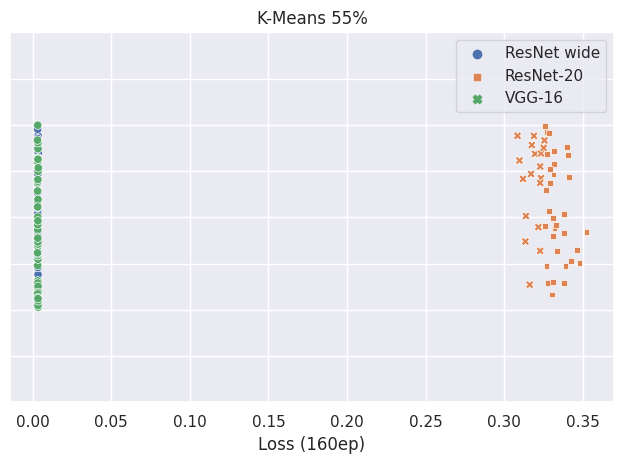

Saving figure to ../outputs/plots/bias/Loss_160ep_Aggregate_CIFAR-100_Logistic_pca.pdf


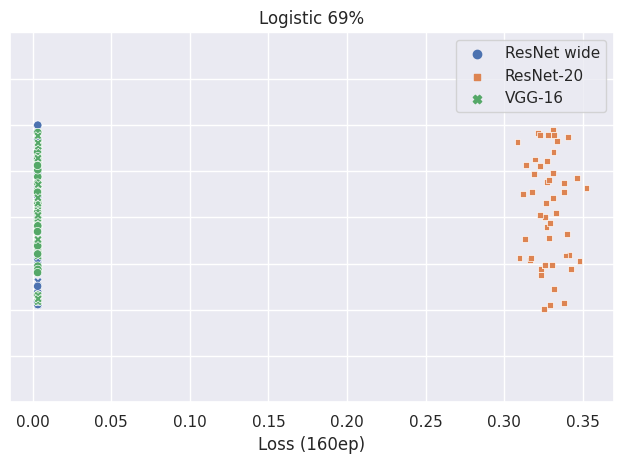

Saving figure to ../outputs/plots/bias/Loss_160ep_Per-Example_CIFAR-100_K-Means_pca.pdf


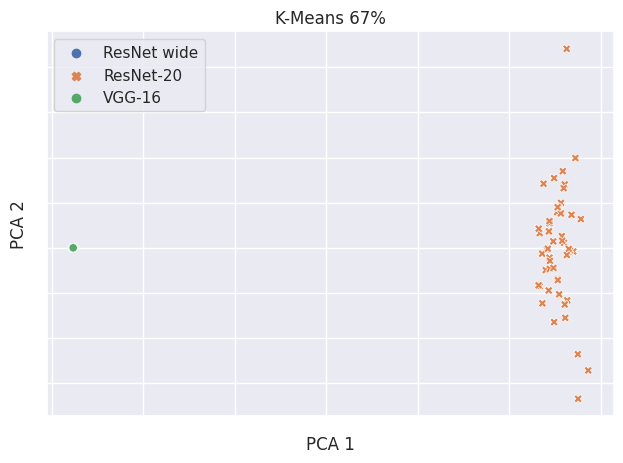

Saving figure to ../outputs/plots/bias/Loss_160ep_Per-Example_CIFAR-100_Logistic_pca.pdf


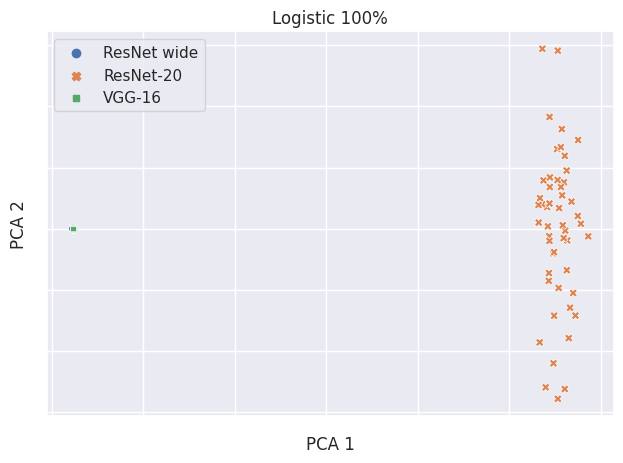

<Figure size 640x480 with 0 Axes>

In [22]:
cifar10_df = dfs[dfs["Dataset"] == "CIFAR-10"]
for dataset, sub_df in dfs.groupby("Dataset"):
    train_and_test(sub_df, FIT_FUNCTIONS, x_label="Loss (160ep)", avg_examples=True, metadata={"Score": "Loss (160ep)", "Type": "Aggregate", "Dataset": dataset}, plot=True)
    train_and_test(sub_df, FIT_FUNCTIONS, avg_examples=False, metadata={"Score": "Loss (160ep)", "Type": "Per-Example", "Dataset": dataset}, plot=True)